In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR, SVR
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import accuracy_score
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
import seaborn as sns

In [ ]:
%%capture
%run '/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/metCost-HeartRate.ipynb'

In [ ]:
pd.set_option('display.max_rows', 2000)
hr_df = final_df
print(hr_df)

In [ ]:
%%capture
%run '/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/metCost-kineticEnergy.ipynb'

In [ ]:
pd.set_option('display.max_rows', 2000)
ke_df = final_df_r
print(ke_df)

In [ ]:
ke_learnDf = ke_df[~ke_df['Subject'].str.contains(r'09|10', regex=True)]
print(ke_learnDf)
ke_testDf = ke_df[ke_df['Subject'].str.contains(r'09|10', regex=True)]
print(ke_testDf)

In [ ]:
%%capture
%run '/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/metCost-acceleration.ipynb'

In [ ]:
pd.set_option('display.max_rows', 2000)
a_df = final_df_r
print(a_df)

In [ ]:
ke_learn_data = ke_learnDf[['ke']]
ee_learn_data = ke_learnDf['ee']

model = LinearRegression()
model.fit(ke_learn_data, ee_learn_data)

ke_test_data = ke_testDf[['ke']]
ee_pred = model.predict(ke_test_data)
ee_test = ke_testDf['ee']

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Evaluate
mse = mean_squared_error(ee_test, ee_pred)
r2 = r2_score(ee_test, ee_pred)

print("Mean Squared Error:", mse)
print("R-squared Score:", r2)

In [ ]:
plt.scatter(ke_test_data, ee_test, color ='blue') 
plt.plot(ke_test_data, ee_pred, color ='red') 
  
plt.show() 

In [ ]:
hr_learnDf = hr_df[~hr_df['Subject'].str.contains(r'09|10', regex=True)]
hr_testDf = hr_df[hr_df['Subject'].str.contains(r'09|10', regex=True)]
print(hr_learnDf)
print(hr_testDf)

hr_learn_data = hr_learnDf[['HR']]
ee_learn_data = hr_learnDf['EE']

model = LinearRegression()
model.fit(hr_learn_data, ee_learn_data)

hr_test_data = hr_testDf[['HR']]
ee_pred = model.predict(hr_test_data)
ee_test = hr_testDf['EE']

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Evaluate
mse = mean_squared_error(ee_test, ee_pred)
r2 = r2_score(ee_test, ee_pred)

print("Mean Squared Error:", mse)
print("R-squared Score:", r2)


plt.scatter(hr_test_data, ee_test, color ='blue') 
plt.plot(hr_test_data, ee_pred, color ='red') 
plt.show() 

In [ ]:
print(hr_df[hr_df['Subject'] == 'Subject06'])
print(ke_df[ke_df['Subject'] == 'Subject06'])


In [ ]:
filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 
# LR_df = LR_df.iloc[:, 1:4]

x = LR_df[["KE", "HR","Sex","Height","Weight"]]  
y = LR_df["EE"] 

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.8, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_test['KE'], x_test['HR'], y_test, c='b', marker='o')

x_range = np.linspace(x_test['KE'].min(), x_test['KE'].max(), 10)
y_range = np.linspace(x_test['HR'].min(), x_test['HR'].max(), 10)
X_plane, Y_plane = np.meshgrid(x_range, y_range)
Z_plane = model.intercept_ + model.coef_[0] * X_plane + model.coef_[1] * Y_plane

ax.plot_surface(X_plane, Y_plane, Z_plane, alpha=0.5)

ax.set_xlabel('KE (J/kg)')
ax.set_ylabel('HR (bpm)')
ax.set_zlabel('EE (J/kg)')

plt.show()

In [ ]:
# SVR train 80%, test 20%
filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 
# Keep only relevant columns (drop "Activity")
LR_df = LR_df[["KE", "HR", "Subject", "EE"]]

# Convert "Subject" (a string) to numeric using Label Encoding
le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  # Assigns numbers to each unique subject

# Define features and target
x = LR_df.drop(columns=["EE"])  # All columns except EE
y = LR_df["EE"]  

# Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Train LinearSVR model
model = LinearSVR(random_state=42, max_iter=1000000)
model.fit(x_train, y_train)

# Make predictions
y_pred = model.predict(x_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")


In [ ]:
filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 
LR_df = LR_df[["KE", "HR", "Subject", "EE"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  # Assigns numbers to each unique subject

x = LR_df.drop(columns=["EE"]) # All columns except EE
y = LR_df["EE"]  

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearSVR(random_state=42, max_iter=1000000)
model.fit(x_train, y_train)

y_testPred = model.predict(x_test)
y_trainPred = model.predict(x_train)

# Evaluatation
mseTest = mean_squared_error(y_test, y_testPred)
mseTrain = mean_squared_error(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)

# Print results
print(f"Train Mean Squared Error: {mseTrain}")
print(f"Test Mean Squared Error: {mseTest}")
print(f"Train R^2 Score: {r2train}")
print(f"Test R^2 Score: {r2test}")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")


In [ ]:
# SVR train 8, test 2
filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "EE","Sex","Height","Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  # Assigns numbers to each unique subject

x = LR_df.drop(columns=["EE"]) # All columns except EE
y = LR_df["EE"]  

# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
train_mask = LR_df["Subject"].isin(range(0, 8))  # Subjects 1-8 for training
x_train, y_train = x[train_mask], y[train_mask]
x_test, y_test = x[~train_mask], y[~train_mask]  # Subjects 9-10 for testing

# print(x_train)
model = LinearSVR(random_state=42, max_iter=1000000)
model.fit(x_train, y_train)

y_testPred = model.predict(x_test)
y_trainPred = model.predict(x_train)

# Evaluatation
mseTest = mean_squared_error(y_test, y_testPred)
mseTrain = mean_squared_error(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)

print(f"Train Mean Squared Error: {mseTrain}")
print(f"Test Mean Squared Error: {mseTest}")
print(f"Train R^2 Score: {r2train}")
print(f"Test R^2 Score: {r2test}")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")


In [ ]:
Lreg_C = 1.5 # Penalty parameter C of the error term
LregSVR = SVR(kernel='linear', C=Lreg_C,epsilon=0.1)
LregSVR.fit(x_train, y_train)
yR_pred = LregSVR.predict(x_train)

linreg = LinearRegression().fit(x_train, y_train)
yL_pred = linreg.predict(x_train)

train_score=LregSVR.score(x_train, y_train)
test_score=LregSVR.score(x_test, y_test)
Ltrain_score=linreg.score(x_train, y_train)
Ltest_score=linreg.score(x_test, y_test)

print(f"Train Score: {train_score}")
print(f"Test Score: {test_score}")
print(f"Linear Train Score: {Ltrain_score}")
print(f"Linear Test Score: {Ltest_score}")



In [ ]:
# SVR train 8, test 2
filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 
LR_df = LR_df[["KE", "HR","Accel", "Subject", "EE","Sex","Height","Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  # Assigns numbers to each unique subject

x = LR_df.drop(columns=["EE","Subject"]) 
y = LR_df["EE"]  

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# print(x_train)
model = LinearSVR(random_state=42, max_iter=1000000)
model.fit(x_train, y_train)

y_testPred = model.predict(x_test)
y_trainPred = model.predict(x_train)

# Evaluatation
mseTest = mean_squared_error(y_test, y_testPred)
mseTrain = mean_squared_error(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)

print(f"Train Mean Squared Error: {mseTrain}")
print(f"Test Mean Squared Error: {mseTest}")
print(f"Train R^2 Score: {r2train}")
print(f"Test R^2 Score: {r2test}")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")


In [ ]:
Lreg_C = 1.5 # Penalty parameter C of the error term
LregSVR = SVR(kernel='linear', C=Lreg_C,epsilon=0.1)
LregSVR.fit(x_train, y_train)
yR_pred = LregSVR.predict(x_train)

linreg = LinearRegression().fit(x_train, y_train)
yL_pred = linreg.predict(x_train)

train_score=LregSVR.score(x_train, y_train)
test_score=LregSVR.score(x_test, y_test)
Ltrain_score=linreg.score(x_train, y_train)
Ltest_score=linreg.score(x_test, y_test)

print(f"Train Score: {train_score}")
print(f"Test Score: {test_score}")
print(f"Linear Train Score: {Ltrain_score}")
print(f"Linear Test Score: {Ltest_score}")



In [ ]:
plt.scatter(x_train['KE'], y_trainPred, label='Train Data')
plt.scatter(x_test['KE'], y_testPred, label='Test Data')
plt.xlabel('KE')
plt.ylabel('EE')
plt.legend()
plt.show()

plt.scatter(x_train['HR'], y_trainPred, label='Train Data')
plt.scatter(x_test['HR'], y_testPred, label='Test Data')
plt.xlabel('HR')
plt.ylabel('EE')
plt.legend()
plt.show()

plt.scatter(x_train['Height'], y_trainPred, label='Train Data')
plt.scatter(x_test['Height'], y_testPred, label='Test Data')
plt.xlabel('Height')
plt.ylabel('EE')
plt.legend()
plt.show()

plt.scatter(x_train['Weight'], y_trainPred, label='Train Data')
plt.scatter(x_test['Weight'], y_testPred, label='Test Data')
plt.xlabel('Weight')
plt.ylabel('EE')
plt.legend()
plt.show()

plt.scatter(x_train['Sex'], y_trainPred, label='Train Data')
plt.scatter(x_test['Sex'], y_testPred, label='Test Data')
plt.xlabel('Sex')
plt.ylabel('EE')
plt.legend()
plt.show()

In [ ]:
plt.scatter(y_train, y_trainPred, label='Test Data')
plt.xlabel('EE GT')
plt.ylabel('EE Pred')
plt.show()

In [ ]:
# SVR train 8, test 2

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "EE","Sex","Height","Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  # Assigns numbers to each unique subject

x = LR_df.drop(columns=["EE"]) # All columns except EE
y = LR_df["EE"]  

# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
train_mask = LR_df["Subject"].isin(range(0, 8))  # Subjects 1-8 for training
x_train, y_train = x[train_mask], y[train_mask]
x_test, y_test = x[~train_mask], y[~train_mask]  # Subjects 9-10 for testing

# print(x_train)
model = SVR(kernel='rbf')
model.fit(x_train, y_train)

y_testPred = model.predict(x_test)
y_trainPred = model.predict(x_train)

# Evaluatation
mseTest = mean_squared_error(y_test, y_testPred)
mseTrain = mean_squared_error(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)

print(f"Train Mean Squared Error: {mseTrain}")
print(f"Test Mean Squared Error: {mseTest}")
print(f"Train R^2 Score: {r2train}")
print(f"Test R^2 Score: {r2test}")
# print(f"Coefficients: {model.coef_}")
# print(f"Intercept: {model.intercept_}") 


In [ ]:
Lreg_C = 1.5 # Penalty parameter C of the error term
LregSVR = SVR(kernel='rbf', C=Lreg_C, epsilon=0.1)
LregSVR.fit(x_train, y_train)
yR_pred = LregSVR.predict(x_train)

linreg = LinearRegression().fit(x_train, y_train)
yL_pred = linreg.predict(x_train)

train_score=LregSVR.score(x_train, y_train)
test_score=LregSVR.score(x_test, y_test)
Ltrain_score=linreg.score(x_train, y_train)
Ltest_score=linreg.score(x_test, y_test)

print(f"Train Score: {train_score}")
print(f"Test Score: {test_score}")
print(f"Linear Train Score: {Ltrain_score}")
print(f"Linear Test Score: {Ltest_score}")



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error


filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 

LR_df = LR_df[["KE", "HR","Accel", "Subject", "EE","Sex","Height","Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  # Assigns numbers to each unique subject

x = LR_df.drop(columns=["EE"]) # All columns except EE
y = LR_df["EE"]  

# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
train_mask = LR_df["Subject"].isin(range(0, 8))  # Subjects 1-8 for training
x_train, y_train = x[train_mask], y[train_mask]
x_test, y_test = x[~train_mask], y[~train_mask]  # Subjects 9-10 for testing

# Create KNN Regressor with k=5
knn_regressor = KNeighborsRegressor(n_neighbors=15)

# Train the model
knn_regressor.fit(x_train, y_train)

# Make predictions
y_pred = knn_regressor.predict(x_test)

# Evaluate performance using Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"KNN Regression MSE: {mse:.2f}")


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Scatter plot: True vs. Predicted EE values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, edgecolor="k", alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Ideal 1:1 line
plt.xlabel("Actual EE")
plt.ylabel("Predicted EE")
plt.title("KNN Regression: True vs. Predicted EE")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error, r2_score

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 
LR_df = LR_df[["KE", "HR","Accel", "Subject", "EE","Sex","Height","Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  # Assigns numbers to each unique subject

x = LR_df.drop(columns=["EE"]) # All columns except EE
y = LR_df["EE"]  

# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
train_mask = LR_df["Subject"].isin(range(0, 8))  # Subjects 1-8 for training
X_train, y_train = x[train_mask], y[train_mask]
X_test, y_test = x[~train_mask], y[~train_mask]  # Subjects 9-10 for testing

# Create Decision Tree Regressor
dt_regressor = DecisionTreeRegressor(max_depth=5, random_state=42)

# Train the model
dt_regressor.fit(X_train, y_train)

# Make predictions
y_pred = dt_regressor.predict(X_test)

# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Decision Tree Regression MSE: {mse:.2f}")
print(f"Decision Tree Regression R² Score: {r2:.2f}")

# --- Visualization ---

# Scatter plot: True vs. Predicted EE values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, edgecolor="k", alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Ideal 1:1 line
plt.xlabel("Actual EE")
plt.ylabel("Predicted EE")
plt.title("Decision Tree Regression: True vs. Predicted EE")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error, r2_score


filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 
LR_df = LR_df[["KE", "HR","Accel", "Subject", "EE","Sex","Height","Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  # Assigns numbers to each unique subject

x = LR_df.drop(columns=["EE"]) # All columns except EE
y = LR_df["EE"]  

# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
train_mask = LR_df["Subject"].isin(range(0, 8))  # Subjects 1-8 for training
X_train, y_train = x[train_mask], y[train_mask]
X_test, y_test = x[~train_mask], y[~train_mask]  # Subjects 9-10 for testing

# Create and train Lasso regression model
alpha = 0.1  
lasso_regressor = Lasso(alpha=alpha)
lasso_regressor.fit(X_train, y_train)

# Make predictions
y_pred = lasso_regressor.predict(X_test)

# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Lasso Regression MSE: {mse:.2f}")
print(f"Lasso Regression R² Score: {r2:.2f}")
print(f"Coefficients: {lasso_regressor.coef_}")


# Scatter plot: True vs. Predicted EE values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, edgecolor="k", alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  
plt.xlabel("Actual EE")
plt.ylabel("Predicted EE")
plt.title(f"Lasso Regression (alpha={alpha}): True vs. Predicted EE")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error, r2_score

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 
LR_df = LR_df[["KE", "HR","Accel", "Subject", "EE","Sex","Height","Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  # Assigns numbers to each unique subject

x = LR_df.drop(columns=["EE"]) # All columns except EE
y = LR_df["EE"]  

# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
train_mask = LR_df["Subject"].isin(range(0, 8))  # Subjects 1-8 for training
X_train, y_train = x[train_mask], y[train_mask]
X_test, y_test = x[~train_mask], y[~train_mask]  # Subjects 9-10 for testing

# Create and train ridge regression model
alpha = 0.1 # Regularization strength
ridge_regressor = Ridge(alpha=alpha)
ridge_regressor.fit(X_train, y_train)

# Make predictions
y_train_pred = ridge_regressor.predict(X_train)
y_test_pred = ridge_regressor.predict(X_test)

# Calculate metrics
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Print results
print(f"Ridge Regression (alpha={alpha})")
print(f"Train MSE: {train_mse:.2f}, Train RMSE: {train_rmse:.2f}, Train R²: {train_r2:.4f}")
print(f"Test MSE: {test_mse:.2f}, Test RMSE: {test_rmse:.2f}, Test R²: {test_r2:.4f}")


# Scatter plot: True vs. Predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_test_pred, edgecolor="k", alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Ridge Regression (alpha={alpha}): True vs. Predicted")
plt.show()



In [ ]:
# SVR train 8, test 2
from sklearn.inspection import permutation_importance
filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 
LR_df = LR_df[["KE", "HR","Accel", "Subject", "EE","Sex","Height","Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  # Assigns numbers to each unique subject


x = LR_df.drop(columns=["EE"]) # All columns except EE
y = LR_df["EE"]  

# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
train_mask = LR_df["Subject"].isin(range(0, 8))  # Subjects 1-8 for training
x_train, y_train = x[train_mask], y[train_mask]
x_test, y_test = x[~train_mask], y[~train_mask]  # Subjects 9-10 for testing

# print(x_train)
model = SVR(kernel='rbf')
model.fit(x_train, y_train)

y_testPred = model.predict(x_test)
y_trainPred = model.predict(x_train)

# Evaluatation
mseTest = mean_squared_error(y_test, y_testPred)
mseTrain = mean_squared_error(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)

print(f"Train Mean Squared Error: {mseTrain}")
print(f"Test Mean Squared Error: {mseTest}")
print(f"Train R^2 Score: {r2train}")
print(f"Test R^2 Score: {r2test}")
# print(f"Coefficients: {model.coef_}")
# print(f"Intercept: {model.intercept_}") 

feat_importance = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42)

# Show results
print('---------------')
print('FEAT IMPORTANCE')
for i, col in enumerate(x.columns):
    print(f"{col}: {feat_importance.importances_mean[i]:.4f} ± {feat_importance.importances_std[i]:.4f}")

In [8]:
# SVR Linear train 8, test 2: MinMaxScaler
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "EE", "Sex", "Height", "Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  

x = LR_df.drop(columns=["EE","Subject"])
y = LR_df["EE"]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(x)
scaled_df = pd.DataFrame(scaled_data, columns=x.columns)

train_mask = LR_df["Subject"].isin(range(0, 8))  
x_train, y_train = scaled_df[train_mask.values], y[train_mask]
x_test, y_test = scaled_df[~train_mask.values], y[~train_mask]

model = SVR(kernel='linear')
model.fit(x_train, y_train)

y_trainPred = model.predict(x_train)
y_testPred = model.predict(x_test)

mseTrain = mean_squared_error(y_train, y_trainPred)
mseTest = mean_squared_error(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)

print(f"Train Mean Squared Error: {mseTrain:.4f}")
print(f"Test Mean Squared Error: {mseTest:.4f}")
print(f"Train R^2 Score: {r2train:.4f}")
print(f"Test R^2 Score: {r2test:.4f}")

# Permutation importance
feat_importance = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42)

print('---------------')
print('FEAT IMPORTANCE')
for i, col in enumerate(x.columns):
    print(f"{col}: {feat_importance.importances_mean[i]:.4f} ± {feat_importance.importances_std[i]:.4f}")


FileNotFoundError: [Errno 2] No such file or directory: '/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv'

In [ ]:
# SVR Linear train 8, test 2: MinMaxScaler
# Removing features with negative importance
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "EE", "Sex", "Height", "Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  

x = LR_df.drop(columns=["EE","Subject","Sex"])
y = LR_df["EE"]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(x)
scaled_df = pd.DataFrame(scaled_data, columns=x.columns)

train_mask = LR_df["Subject"].isin(range(0, 8))  
x_train, y_train = scaled_df[train_mask.values], y[train_mask]
x_test, y_test = scaled_df[~train_mask.values], y[~train_mask]

model = SVR(kernel='linear')
model.fit(x_train, y_train)

y_trainPred = model.predict(x_train)
y_testPred = model.predict(x_test)

mseTrain = mean_squared_error(y_train, y_trainPred)
mseTest = mean_squared_error(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)

print(f"Train Mean Squared Error: {mseTrain:.4f}")
print(f"Test Mean Squared Error: {mseTest:.4f}")
print(f"Train R^2 Score: {r2train:.4f}")
print(f"Test R^2 Score: {r2test:.4f}")

# Permutation importance
feat_importance = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42)

print('---------------')
print('FEAT IMPORTANCE')
for i, col in enumerate(x.columns):
    print(f"{col}: {feat_importance.importances_mean[i]:.4f} ± {feat_importance.importances_std[i]:.4f}")

In [ ]:
# SVR rbf train 8, test 2: MinMaxScaler
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "EE", "Sex", "Height", "Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  

x = LR_df.drop(columns=["EE","Subject"])
y = LR_df["EE"]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(x)
scaled_df = pd.DataFrame(scaled_data, columns=x.columns)

train_mask = LR_df["Subject"].isin(range(0, 8))  
x_train, y_train = scaled_df[train_mask.values], y[train_mask]
x_test, y_test = scaled_df[~train_mask.values], y[~train_mask]

model = SVR(kernel='rbf')
model.fit(x_train, y_train)

y_trainPred = model.predict(x_train)
y_testPred = model.predict(x_test)

mseTrain = mean_squared_error(y_train, y_trainPred)
mseTest = mean_squared_error(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)

print(f"Train Mean Squared Error: {mseTrain:.4f}")
print(f"Test Mean Squared Error: {mseTest:.4f}")
print(f"Train R^2 Score: {r2train:.4f}")
print(f"Test R^2 Score: {r2test:.4f}")

# Permutation importance
feat_importance = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42)

print('---------------')
print('FEAT IMPORTANCE')
for i, col in enumerate(x.columns):
    print(f"{col}: {feat_importance.importances_mean[i]:.4f} ± {feat_importance.importances_std[i]:.4f}")


In [ ]:
# SVR RBF train 8, test 2: MinMaxScaler
# Removing features with negative importance
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "EE", "Sex", "Height", "Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  

x = LR_df.drop(columns=["EE","Subject","Sex"])
y = LR_df["EE"]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(x)
scaled_df = pd.DataFrame(scaled_data, columns=x.columns)

train_mask = LR_df["Subject"].isin(range(0, 8))  
x_train, y_train = scaled_df[train_mask.values], y[train_mask]
x_test, y_test = scaled_df[~train_mask.values], y[~train_mask]

model = SVR(kernel='rbf')
model.fit(x_train, y_train)

y_trainPred = model.predict(x_train)
y_testPred = model.predict(x_test)

mseTrain = mean_squared_error(y_train, y_trainPred)
mseTest = mean_squared_error(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)

print(f"Train Mean Squared Error: {mseTrain:.4f}")
print(f"Test Mean Squared Error: {mseTest:.4f}")
print(f"Train R^2 Score: {r2train:.4f}")
print(f"Test R^2 Score: {r2test:.4f}")

# Permutation importance
feat_importance = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42)

print('---------------')
print('FEAT IMPORTANCE')
for i, col in enumerate(x.columns):
    print(f"{col}: {feat_importance.importances_mean[i]:.4f} ± {feat_importance.importances_std[i]:.4f}")

In [9]:
# SVR Linear train 8, test 2: MinMaxScaler
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "EE", "Sex", "Height", "Weight","EMG2","EMG3", "EMG4", "EMG5", "EMG6", "EMG7", "EMG8", "EMG9", "EMG10", "EMG11", "EMG12", "EMG13", "EMG14", "EMG15", "EMG16","EMG17"]]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  

x = LR_df.drop(columns=["EE","Subject"])
y = LR_df["EE"]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(x)
scaled_df = pd.DataFrame(scaled_data, columns=x.columns)

train_mask = LR_df["Subject"].isin(range(0,8))
x_train, y_train = scaled_df[train_mask.values], y[train_mask]
x_test, y_test = scaled_df[~train_mask.values], y[~train_mask]

model = SVR(kernel='linear')
model.fit(x_train, y_train)

y_trainPred = model.predict(x_train)
y_testPred = model.predict(x_test)

mseTrain = mean_squared_error(y_train, y_trainPred)
mseTest = mean_squared_error(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)

print(f"Train Mean Squared Error: {mseTrain:.4f}")
print(f"Test Mean Squared Error: {mseTest:.4f}")
print(f"Train R^2 Score: {r2train:.4f}")
print(f"Test R^2 Score: {r2test:.4f}")

# Permutation importance
feat_importance = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42)

print('---------------')
print('FEAT IMPORTANCE')
for i, col in enumerate(x.columns):
    print(f"{col}: {feat_importance.importances_mean[i]:.4f} ± {feat_importance.importances_std[i]:.4f}")


Train Mean Squared Error: 1.0682
Test Mean Squared Error: 0.8958
Train R^2 Score: 0.8928
Test R^2 Score: 0.8828
---------------
FEAT IMPORTANCE
KE: 0.0446 ± 0.0046
HR: 0.5304 ± 0.0613
Accel: 0.0551 ± 0.0079
Sex: 0.0243 ± 0.0032
Height: -0.0012 ± 0.0003
Weight: 0.0096 ± 0.0046
EMG2: 0.0005 ± 0.0006
EMG3: 0.0005 ± 0.0008
EMG4: 0.0210 ± 0.0034
EMG5: 0.0157 ± 0.0027
EMG6: -0.0026 ± 0.0019
EMG7: 0.0106 ± 0.0025
EMG8: 0.0389 ± 0.0048
EMG9: 0.0042 ± 0.0013
EMG10: 0.0002 ± 0.0001
EMG11: 0.0008 ± 0.0024
EMG12: 0.0070 ± 0.0041
EMG13: 0.0055 ± 0.0010
EMG14: 0.1154 ± 0.0136
EMG15: 0.0166 ± 0.0031
EMG16: 0.0062 ± 0.0020
EMG17: 0.0001 ± 0.0001


In [11]:
# SVR Linear train 8, test 2 ; MinMaxScaler ; leave 2 subjects out CV
from sklearn.model_selection import LeavePOut
from sklearn.pipeline import make_pipeline
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "EE", "Sex", "Height", "Weight","EMG2","EMG3", "EMG4", "EMG5", "EMG6", "EMG7", "EMG8", "EMG9", "EMG10", "EMG11", "EMG12", "EMG13", "EMG14", "EMG15", "EMG16","EMG17"]]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  

x = LR_df.drop(columns=["EE","Subject"])
y = LR_df["EE"]

subjects = LR_df["Subject"].values
uniqueSubjects = np.unique(subjects)

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(x)
scaled_df = pd.DataFrame(scaled_data, columns=x.columns)

model = make_pipeline(MinMaxScaler(), SVR(kernel="linear"))
lpo = LeavePOut(p = 2)

mseTrain, mseTest, r2train, r2test = [], [], [], []

for train_subject_idx, test_subject_idx in lpo.split(uniqueSubjects):
    train_subs = uniqueSubjects[train_subject_idx]
    test_subs = uniqueSubjects[test_subject_idx]

    train_mask = np.isin(subjects, train_subs)
    test_mask  = np.isin(subjects, test_subs)

    x_train, x_test = x[train_mask], x[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]

    model.fit(x_train, y_train)
    y_trainPred = model.predict(x_train)
    y_testPred = model.predict(x_test)

    mseTrain.append(mean_squared_error(y_train, y_trainPred))
    mseTest.append(mean_squared_error(y_test, y_testPred))
    r2train.append(r2_score(y_train, y_trainPred))
    r2test.append(r2_score(y_test, y_testPred))
    

print(f"Average MSE Train: {np.mean(mseTrain):.4f}")
print(f"Average MSE Test: {np.mean(mseTest):.4f}")
print(f"Average R² Train:  {np.mean(r2train):.4f}")
print(f"Average R² Test:  {np.mean(r2test):.4f}")

Average MSE Train: 0.9708
Average MSE Test: 2.3830
Average R² Train:  0.8983
Average R² Test:  0.7464


In [59]:
# SVR Linear train 8, test 2 ; MinMaxScaler ; 5 fold subject CV
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
import numpy as np
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd
import seaborn as sns

# Load dataset
filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "Activity", "EE", "Sex", "Height", "Weight",
               "EMG2","EMG3", "EMG4", "EMG5", "EMG6", "EMG7", "EMG8", "EMG9", "EMG10", 
               "EMG11", "EMG12", "EMG13", "EMG14", "EMG15", "EMG16","EMG17"]]
LR_df.fillna(0, inplace=True)

# Encode subjects but keep original labels for printing
le = LabelEncoder()
LR_df["Subject_enc"] = le.fit_transform(LR_df["Subject"])
subjects = LR_df["Subject_enc"].values
original_subject_labels = LR_df["Subject"].values

x = LR_df.drop(columns=["EE", "Subject", "Activity"])
y = LR_df["EE"]

uniqueSubjects = np.unique(subjects)

model = make_pipeline(MinMaxScaler(), SVR(kernel="linear"))
gkf = GroupKFold(n_splits=10)

mseTrain, mseTest, r2train, r2test = [], [], [], []

for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(x, y, groups=subjects), start=1):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Get ORIGINAL subject labels instead of encoded ones
    test_subjects = np.unique(original_subject_labels[test_idx])

    model.fit(x_train, y_train)
    y_trainPred = model.predict(x_train)
    y_testPred = model.predict(x_test)

    fold_mse_train = mean_squared_error(y_train, y_trainPred)
    fold_mse_test = mean_squared_error(y_test, y_testPred)
    fold_r2_train = r2_score(y_train, y_trainPred)
    fold_r2_test = r2_score(y_test, y_testPred)

    mseTrain.append(fold_mse_train)
    mseTest.append(fold_mse_test)
    r2train.append(fold_r2_train)
    r2test.append(fold_r2_test)

    # Print per-fold results
    print(f"Test Subjects: {test_subjects}")
    print(f"     Train MSE: {fold_mse_train:.4f} , Test MSE: {fold_mse_test:.4f}")
    print(f"     Train R²:  {fold_r2_train:.4f} , Test R²:  {fold_r2_test:.4f}")
    print("\n")

print("\n")
print(f"Average MSE Train: {np.mean(mseTrain):.4f} , Average MSE Test: {np.mean(mseTest):.4f}")
print(f"Average R² Train:  {np.mean(r2train):.4f} , Average R² Test:  {np.mean(r2test):.4f}")


Test Subjects: ['Subject09']
     Train MSE: 1.0444 , Test MSE: 1.0696
     Train R²:  0.8904 , Test R²:  0.8896


Test Subjects: ['Subject08']
     Train MSE: 1.0583 , Test MSE: 0.9154
     Train R²:  0.8925 , Test R²:  0.8669


Test Subjects: ['Subject06']
     Train MSE: 1.0085 , Test MSE: 1.5059
     Train R²:  0.8947 , Test R²:  0.8384


Test Subjects: ['Subject07']
     Train MSE: 0.9017 , Test MSE: 2.5957
     Train R²:  0.9007 , Test R²:  0.7988


Test Subjects: ['Subject03']
     Train MSE: 0.9526 , Test MSE: 7.8611
     Train R²:  0.8996 , Test R²:  0.1985


Test Subjects: ['Subject02']
     Train MSE: 1.0212 , Test MSE: 2.0082
     Train R²:  0.8912 , Test R²:  0.8145


Test Subjects: ['Subject04']
     Train MSE: 1.0014 , Test MSE: 1.7828
     Train R²:  0.8953 , Test R²:  0.8106


Test Subjects: ['Subject10']
     Train MSE: 1.0424 , Test MSE: 0.7165
     Train R²:  0.8951 , Test R²:  0.8251


Test Subjects: ['Subject05']
     Train MSE: 0.9678 , Test MSE: 2.2491
     Trai

Test Subject: Subject09
     Train MSE: 1.0444 , Test MSE: 1.0696
     Train R²:  0.8904 , Test R²:  0.8896

Test Subject: Subject08
     Train MSE: 1.0583 , Test MSE: 0.9154
     Train R²:  0.8925 , Test R²:  0.8669

Test Subject: Subject06
     Train MSE: 1.0085 , Test MSE: 1.5059
     Train R²:  0.8947 , Test R²:  0.8384

Test Subject: Subject07
     Train MSE: 0.9017 , Test MSE: 2.5957
     Train R²:  0.9007 , Test R²:  0.7988

Test Subject: Subject03
     Train MSE: 0.9526 , Test MSE: 7.8611
     Train R²:  0.8996 , Test R²:  0.1985

Test Subject: Subject02
     Train MSE: 1.0212 , Test MSE: 2.0082
     Train R²:  0.8912 , Test R²:  0.8145

Test Subject: Subject04
     Train MSE: 1.0014 , Test MSE: 1.7828
     Train R²:  0.8953 , Test R²:  0.8106

Test Subject: Subject10
     Train MSE: 1.0424 , Test MSE: 0.7165
     Train R²:  0.8951 , Test R²:  0.8251

Test Subject: Subject05
     Train MSE: 0.9678 , Test MSE: 2.2491
     Train R²:  0.8958 , Test R²:  0.8099

Test Subject: Subje

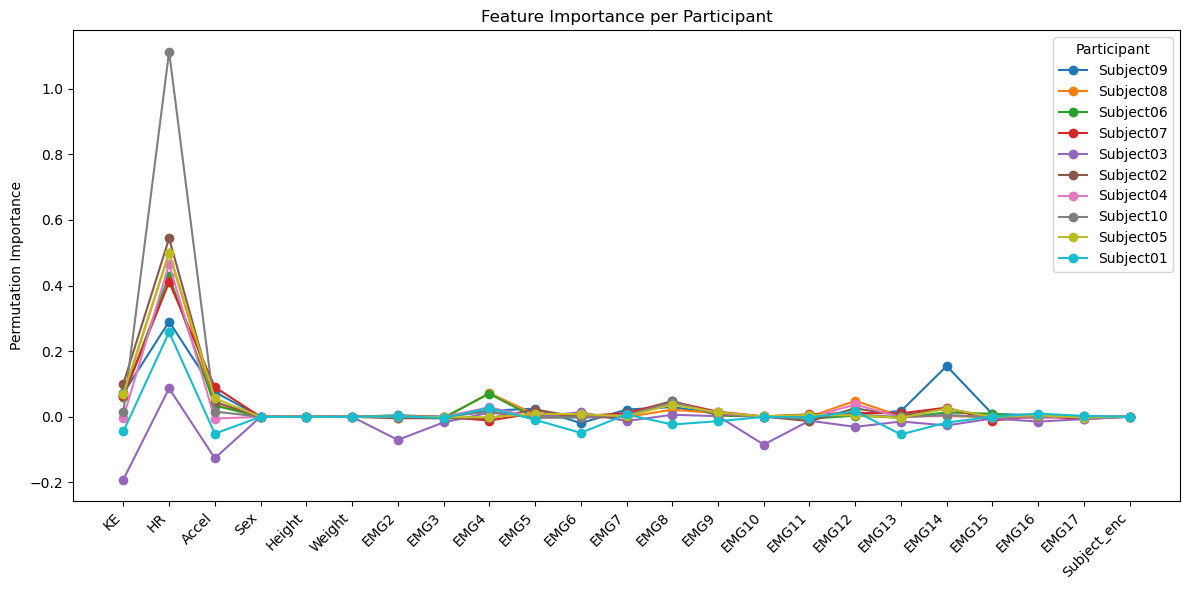

In [63]:
# SVR Linear train 8, test 2 ; MinMaxScaler ; 10 fold subject CV with per-fold permutation importance
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
import numpy as np
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "Activity", "EE", "Sex", "Height", "Weight",
               "EMG2","EMG3", "EMG4", "EMG5", "EMG6", "EMG7", "EMG8", "EMG9", "EMG10", 
               "EMG11", "EMG12", "EMG13", "EMG14", "EMG15", "EMG16","EMG17"]]
LR_df.fillna(0, inplace=True)

# Encode subjects but keep original labels
le = LabelEncoder()
LR_df["Subject_enc"] = le.fit_transform(LR_df["Subject"])
subjects = LR_df["Subject_enc"].values
original_subject_labels = LR_df["Subject"].values

x = LR_df.drop(columns=["EE", "Subject", "Activity"])
y = LR_df["EE"]

model = make_pipeline(MinMaxScaler(), SVR(kernel="linear"))
gkf = GroupKFold(n_splits=10)

mseTrain, mseTest, r2train, r2test = [], [], [], []

# Store feature importance per fold
fold_feature_importance = []
fold_subjects = []

for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(x, y, groups=subjects), start=1):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Original subject label for this fold (single participant per fold)
    test_subject = np.unique(original_subject_labels[test_idx])[0]
    fold_subjects.append(test_subject)

    # Fit model
    model.fit(x_train, y_train)
    y_trainPred = model.predict(x_train)
    y_testPred = model.predict(x_test)

    # Metrics
    fold_mse_train = mean_squared_error(y_train, y_trainPred)
    fold_mse_test = mean_squared_error(y_test, y_testPred)
    fold_r2_train = r2_score(y_train, y_trainPred)
    fold_r2_test = r2_score(y_test, y_testPred)

    mseTrain.append(fold_mse_train)
    mseTest.append(fold_mse_test)
    r2train.append(fold_r2_train)
    r2test.append(fold_r2_test)

    # Permutation importance on test set for this fold
    perm_importance = permutation_importance(model, x_test, y_test, random_state=42)
    fold_feature_importance.append(perm_importance.importances_mean)

    # Print per-fold results
    print(f"Test Subject: {test_subject}")
    print(f"     Train MSE: {fold_mse_train:.4f} , Test MSE: {fold_mse_test:.4f}")
    print(f"     Train R²:  {fold_r2_train:.4f} , Test R²:  {fold_r2_test:.4f}\n")

# Average metrics
print("\n")
print(f"Average MSE Train: {np.mean(mseTrain):.4f} , Average MSE Test: {np.mean(mseTest):.4f}")
print(f"Average R² Train:  {np.mean(r2train):.4f} , Average R² Test:  {np.mean(r2test):.4f}")

# Convert feature importance list to DataFrame for plotting
fi_df = pd.DataFrame(fold_feature_importance, columns=x.columns)

# Plot feature importance per participant
plt.figure(figsize=(12, 6))
for idx, subject in enumerate(fold_subjects):
    plt.plot(x.columns, fi_df.iloc[idx], marker='o', label=subject)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Permutation Importance")
plt.title("Feature Importance per Participant")
plt.legend(title="Participant")
plt.tight_layout()
plt.show()


In [14]:
# SVR Linear train 8, test 2 ; MinMaxScaler ; 5 fold subject CV
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "Activity", "EE", "Sex", "Height", "Weight","EMG2","EMG3", "EMG4", "EMG5", "EMG6", "EMG7", "EMG8", "EMG9", "EMG10", "EMG11", "EMG12", "EMG13", "EMG14", "EMG15", "EMG16","EMG17"]]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  

x = LR_df.drop(columns=["EE","Subject","Activity"])
y = LR_df["EE"]

subjects = LR_df["Subject"].values
uniqueSubjects = np.unique(subjects)

model = make_pipeline(MinMaxScaler(), SVR(kernel="linear"))
gkf = GroupKFold(n_splits=5)

mseTrain, mseTest, r2train, r2test = [], [], [], []

for train_idx, test_idx in gkf.split(x, y, groups=subjects):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(x_train, y_train)
    y_trainPred = model.predict(x_train)
    y_testPred = model.predict(x_test)

    mseTrain.append(mean_squared_error(y_train, y_trainPred))
    mseTest.append(mean_squared_error(y_test, y_testPred))
    r2train.append(r2_score(y_train, y_trainPred))
    r2test.append(r2_score(y_test, y_testPred))
    

print(f"Average MSE Train: {np.mean(mseTrain):.4f}")
print(f"Average MSE Test: {np.mean(mseTest):.4f}")
print(f"Average R² Train:  {np.mean(r2train):.4f}")
print(f"Average R² Test:  {np.mean(r2test):.4f}")

Average MSE Train: 0.9763
Average MSE Test: 1.9403
Average R² Train:  0.8978
Average R² Test:  0.7915


In [15]:
# SVR Linear train 5, test 1 ; MinMaxScaler ; 6-fold CV by Activity
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "Activity", "EE", "Sex", "Height", "Weight","EMG2","EMG3", "EMG4", "EMG5", "EMG6", "EMG7", "EMG8", "EMG9", "EMG10", "EMG11", "EMG12", "EMG13", "EMG14", "EMG15", "EMG16","EMG17"]]
LR_df.fillna(0, inplace=True)

le_s = LabelEncoder()
LR_df["Subject"] = le_s.fit_transform(LR_df["Subject"])  
le_a = LabelEncoder()
LR_df["Activity"] = le_a.fit_transform(LR_df["Activity"])  

x = LR_df.drop(columns=["EE","Subject","Activity"])
y = LR_df["EE"]

activity = LR_df["Activity"].values

model = make_pipeline(MinMaxScaler(), SVR(kernel="linear"))
gkf = GroupKFold(n_splits=6)

mseTrain, mseTest, r2train, r2test = [], [], [], []

for train_idx, test_idx in gkf.split(x, y, groups=activity):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(x_train, y_train)
    y_trainPred = model.predict(x_train)
    y_testPred = model.predict(x_test)

    mseTrain.append(mean_squared_error(y_train, y_trainPred))
    mseTest.append(mean_squared_error(y_test, y_testPred))
    r2train.append(r2_score(y_train, y_trainPred))
    r2test.append(r2_score(y_test, y_testPred))
    

print(f"Average MSE Train: {np.mean(mseTrain):.4f}")
print(f"Average MSE Test: {np.mean(mseTest):.4f}")
print(f"Average R² Train:  {np.mean(r2train):.4f}")
print(f"Average R² Test:  {np.mean(r2test):.4f}")


Average MSE Train: 0.9628
Average MSE Test: 3.3960
Average R² Train:  0.8944
Average R² Test:  0.3113


In [16]:
# SVR Linear train 8, test 2: MinMaxScaler
# Removing features with negative importance
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "EE", "Sex", "Weight","EMG2","EMG3", "EMG4", "EMG5", "EMG7","EMG8", "EMG9", "EMG10", "EMG11", "EMG12", "EMG13", "EMG14", "EMG15", "EMG16","EMG17"]]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  

x = LR_df.drop(columns=["EE","Subject","Sex"])
y = LR_df["EE"]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(x)
scaled_df = pd.DataFrame(scaled_data, columns=x.columns)

train_mask = LR_df["Subject"].isin(range(0, 8))  
x_train, y_train = scaled_df[train_mask.values], y[train_mask]
x_test, y_test = scaled_df[~train_mask.values], y[~train_mask]

model = SVR(kernel='linear')
model.fit(x_train, y_train)

y_trainPred = model.predict(x_train)
y_testPred = model.predict(x_test)

mseTrain = mean_squared_error(y_train, y_trainPred)
mseTest = mean_squared_error(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)

print(f"Train Mean Squared Error: {mseTrain:.4f}")
print(f"Test Mean Squared Error: {mseTest:.4f}")
print(f"Train R^2 Score: {r2train:.4f}")
print(f"Test R^2 Score: {r2test:.4f}")

# Permutation importance
feat_importance = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42)

print('---------------')
print('FEAT IMPORTANCE')
for i, col in enumerate(x.columns):
    print(f"{col}: {feat_importance.importances_mean[i]:.4f} ± {feat_importance.importances_std[i]:.4f}")

Train Mean Squared Error: 1.1051
Test Mean Squared Error: 0.9964
Train R^2 Score: 0.8891
Test R^2 Score: 0.8696
---------------
FEAT IMPORTANCE
KE: 0.0519 ± 0.0052
HR: 0.5293 ± 0.0603
Accel: 0.0470 ± 0.0074
Weight: -0.0097 ± 0.0047
EMG2: -0.0026 ± 0.0006
EMG3: 0.0008 ± 0.0009
EMG4: 0.0207 ± 0.0036
EMG5: 0.0071 ± 0.0027
EMG7: 0.0083 ± 0.0029
EMG8: 0.0176 ± 0.0046
EMG9: -0.0006 ± 0.0006
EMG10: -0.0006 ± 0.0003
EMG11: 0.0006 ± 0.0033
EMG12: -0.0025 ± 0.0034
EMG13: 0.0005 ± 0.0006
EMG14: 0.0517 ± 0.0080
EMG15: 0.0187 ± 0.0033
EMG16: 0.0022 ± 0.0024
EMG17: -0.0022 ± 0.0008


In [17]:
# SVR rbf train 8, test 2: MinMaxScaler
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "EE", "Sex", "Height", "Weight","EMG2","EMG3", "EMG4", "EMG5", "EMG6", "EMG7", "EMG8", "EMG9", "EMG10", "EMG11", "EMG12", "EMG13", "EMG14", "EMG15", "EMG16","EMG17"]]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  

x = LR_df.drop(columns=["EE","Subject"])
y = LR_df["EE"]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(x)
scaled_df = pd.DataFrame(scaled_data, columns=x.columns)

train_mask = LR_df["Subject"].isin(range(0, 8))  
x_train, y_train = scaled_df[train_mask.values], y[train_mask]
x_test, y_test = scaled_df[~train_mask.values], y[~train_mask]

model = SVR(kernel='rbf')
model.fit(x_train, y_train)

y_trainPred = model.predict(x_train)
y_testPred = model.predict(x_test)

mseTrain = mean_squared_error(y_train, y_trainPred)
mseTest = mean_squared_error(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)

print(f"Train Mean Squared Error: {mseTrain:.4f}")
print(f"Test Mean Squared Error: {mseTest:.4f}")
print(f"Train R^2 Score: {r2train:.4f}")
print(f"Test R^2 Score: {r2test:.4f}")

# Permutation importance
feat_importance = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42)

print('---------------')
print('FEAT IMPORTANCE')
for i, col in enumerate(x.columns):
    print(f"{col}: {feat_importance.importances_mean[i]:.4f} ± {feat_importance.importances_std[i]:.4f}")


Train Mean Squared Error: 0.5380
Test Mean Squared Error: 1.7831
Train R^2 Score: 0.9460
Test R^2 Score: 0.7667
---------------
FEAT IMPORTANCE
KE: 0.0411 ± 0.0054
HR: 0.3368 ± 0.0404
Accel: 0.0850 ± 0.0128
Sex: 0.0260 ± 0.0071
Height: -0.0038 ± 0.0083
Weight: -0.0221 ± 0.0084
EMG2: 0.0000 ± 0.0011
EMG3: 0.0025 ± 0.0038
EMG4: 0.0075 ± 0.0037
EMG5: 0.0444 ± 0.0110
EMG6: 0.0093 ± 0.0048
EMG7: 0.0255 ± 0.0058
EMG8: 0.0284 ± 0.0057
EMG9: 0.0253 ± 0.0040
EMG10: 0.0008 ± 0.0013
EMG11: 0.0119 ± 0.0056
EMG12: 0.0359 ± 0.0095
EMG13: 0.0307 ± 0.0076
EMG14: 0.0488 ± 0.0092
EMG15: 0.0167 ± 0.0059
EMG16: 0.0225 ± 0.0040
EMG17: 0.0157 ± 0.0032


In [18]:
# SVR rbf train 8, test 2: MinMaxScaler
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "EE", "Sex","EMG3", "EMG4", "EMG5", "EMG6", "EMG7", "EMG8", "EMG9", "EMG10", "EMG11", "EMG12", "EMG13", "EMG14", "EMG15", "EMG16","EMG17"]]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  

x = LR_df.drop(columns=["EE","Subject"])
y = LR_df["EE"]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(x)
scaled_df = pd.DataFrame(scaled_data, columns=x.columns)

train_mask = LR_df["Subject"].isin(range(0, 8))  
x_train, y_train = scaled_df[train_mask.values], y[train_mask]
x_test, y_test = scaled_df[~train_mask.values], y[~train_mask]

model = SVR(kernel='rbf')
model.fit(x_train, y_train)

y_trainPred = model.predict(x_train)
y_testPred = model.predict(x_test)

mseTrain = mean_squared_error(y_train, y_trainPred)
mseTest = mean_squared_error(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)

print(f"Train Mean Squared Error: {mseTrain:.4f}")
print(f"Test Mean Squared Error: {mseTest:.4f}")
print(f"Train R^2 Score: {r2train:.4f}")
print(f"Test R^2 Score: {r2test:.4f}")

# Permutation importance
feat_importance = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42)

print('---------------')
print('FEAT IMPORTANCE')
for i, col in enumerate(x.columns):
    print(f"{col}: {feat_importance.importances_mean[i]:.4f} ± {feat_importance.importances_std[i]:.4f}")


Train Mean Squared Error: 0.6778
Test Mean Squared Error: 1.8129
Train R^2 Score: 0.9320
Test R^2 Score: 0.7628
---------------
FEAT IMPORTANCE
KE: 0.0847 ± 0.0118
HR: 0.3733 ± 0.0476
Accel: 0.1084 ± 0.0140
Sex: 0.0396 ± 0.0070
EMG3: 0.0323 ± 0.0081
EMG4: 0.0154 ± 0.0056
EMG5: 0.0548 ± 0.0118
EMG6: 0.0421 ± 0.0094
EMG7: 0.0308 ± 0.0067
EMG8: 0.0589 ± 0.0057
EMG9: 0.0429 ± 0.0041
EMG10: 0.0030 ± 0.0008
EMG11: 0.0211 ± 0.0097
EMG12: 0.0978 ± 0.0219
EMG13: 0.0292 ± 0.0054
EMG14: 0.0616 ± 0.0113
EMG15: 0.0290 ± 0.0096
EMG16: 0.0338 ± 0.0039
EMG17: 0.0300 ± 0.0042


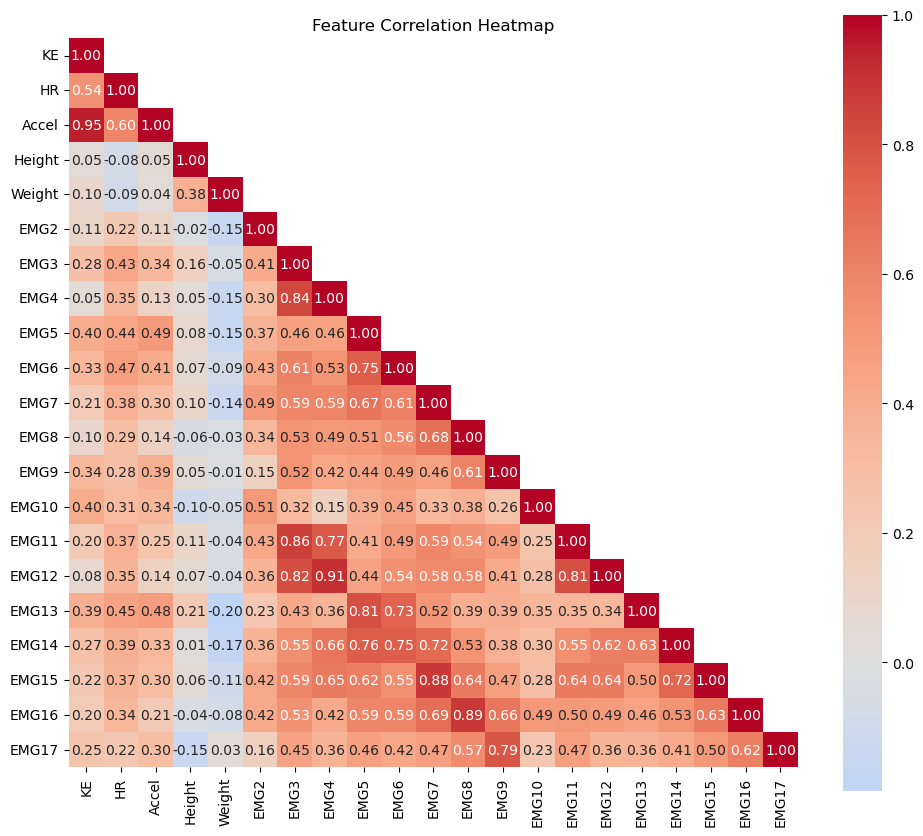

In [27]:
# Feature Correlations
filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Height", "Weight", "EMG2", "EMG3", "EMG4", "EMG5", "EMG6", "EMG7", "EMG8", "EMG9", "EMG10", "EMG11", "EMG12", "EMG13", "EMG14", "EMG15", "EMG16","EMG17"]]
LR_df.fillna(0, inplace=True)

correlation_matrix = LR_df.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)

plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix,
            mask=mask,           
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={"shrink": .8})

plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [29]:
# SVR Linear train 8, test 2: MinMaxScaler
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Subject", "EE", "Sex", "Height", "Weight","EMG2","EMG3", "EMG5", "EMG6", "EMG7", "EMG8", "EMG9", "EMG10", "EMG14"]]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  

x = LR_df.drop(columns=["EE","Subject"])
y = LR_df["EE"]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(x)
scaled_df = pd.DataFrame(scaled_data, columns=x.columns)

train_mask = LR_df["Subject"].isin(range(0,8))
x_train, y_train = scaled_df[train_mask.values], y[train_mask]
x_test, y_test = scaled_df[~train_mask.values], y[~train_mask]

model = SVR(kernel='linear')
model.fit(x_train, y_train)

y_trainPred = model.predict(x_train)
y_testPred = model.predict(x_test)

mseTrain = mean_squared_error(y_train, y_trainPred)
mseTest = mean_squared_error(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)

print(f"Train Mean Squared Error: {mseTrain:.4f}")
print(f"Test Mean Squared Error: {mseTest:.4f}")
print(f"Train R^2 Score: {r2train:.4f}")
print(f"Test R^2 Score: {r2test:.4f}")

# Permutation importance
feat_importance = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42)

print('---------------')
print('FEAT IMPORTANCE')
for i, col in enumerate(x.columns):
    print(f"{col}: {feat_importance.importances_mean[i]:.4f} ± {feat_importance.importances_std[i]:.4f}")


Train Mean Squared Error: 1.1194
Test Mean Squared Error: 0.7306
Train R^2 Score: 0.8876
Test R^2 Score: 0.9044
---------------
FEAT IMPORTANCE
KE: 0.1266 ± 0.0092
HR: 0.5449 ± 0.0643
Sex: 0.0278 ± 0.0033
Height: -0.0018 ± 0.0004
Weight: 0.0097 ± 0.0039
EMG2: -0.0002 ± 0.0006
EMG3: 0.0001 ± 0.0000
EMG5: 0.0336 ± 0.0043
EMG6: -0.0011 ± 0.0006
EMG7: 0.0029 ± 0.0019
EMG8: 0.0543 ± 0.0061
EMG9: 0.0045 ± 0.0013
EMG10: 0.0004 ± 0.0003
EMG14: 0.0600 ± 0.0079


In [66]:
# SVR Linear train 8, test 2 ; MinMaxScaler ; 5 fold subject CV
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
import numpy as np
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd
import seaborn as sns

# Load dataset
filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Subject", "EE", "Sex", "Height", "Weight","EMG2","EMG3", "EMG5", "EMG8", "EMG9"]]
LR_df.fillna(0, inplace=True)

# Encode subjects but keep original labels for printing
le = LabelEncoder()
LR_df["Subject_enc"] = le.fit_transform(LR_df["Subject"])
subjects = LR_df["Subject_enc"].values
original_subject_labels = LR_df["Subject"].values

x = LR_df.drop(columns=["EE", "Subject"])
y = LR_df["EE"]

uniqueSubjects = np.unique(subjects)

model = make_pipeline(MinMaxScaler(), SVR(kernel="linear"))
gkf = GroupKFold(n_splits=10)

mseTrain, mseTest, r2train, r2test = [], [], [], []

for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(x, y, groups=subjects), start=1):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Get ORIGINAL subject labels instead of encoded ones
    test_subject = np.unique(original_subject_labels[test_idx])[0]

    model.fit(x_train, y_train)
    y_trainPred = model.predict(x_train)
    y_testPred = model.predict(x_test)

    fold_mse_train = mean_squared_error(y_train, y_trainPred)
    fold_mse_test = mean_squared_error(y_test, y_testPred)
    fold_r2_train = r2_score(y_train, y_trainPred)
    fold_r2_test = r2_score(y_test, y_testPred)

    mseTrain.append(fold_mse_train)
    mseTest.append(fold_mse_test)
    r2train.append(fold_r2_train)
    r2test.append(fold_r2_test)

    # Print per-fold results
    print(f"Test Subject: {test_subject}")
    print(f"     Train MSE: {fold_mse_train:.4f} , Test MSE: {fold_mse_test:.4f}")
    print(f"     Train R²:  {fold_r2_train:.4f} , Test R²:  {fold_r2_test:.4f}")
    print("\n")

print("\n")
print(f"Average MSE Train: {np.mean(mseTrain):.4f} , Average MSE Test: {np.mean(mseTest):.4f}")
print(f"Average R² Train:  {np.mean(r2train):.4f} , Average R² Test:  {np.mean(r2test):.4f}")


Test Subject: Subject09
     Train MSE: 1.1023 , Test MSE: 0.8538
     Train R²:  0.8843 , Test R²:  0.9119


Test Subject: Subject08
     Train MSE: 1.0994 , Test MSE: 0.8599
     Train R²:  0.8884 , Test R²:  0.8750


Test Subject: Subject06
     Train MSE: 1.0400 , Test MSE: 1.4187
     Train R²:  0.8914 , Test R²:  0.8478


Test Subject: Subject07
     Train MSE: 0.9774 , Test MSE: 3.2783
     Train R²:  0.8924 , Test R²:  0.7459


Test Subject: Subject03
     Train MSE: 1.0541 , Test MSE: 1.4644
     Train R²:  0.8888 , Test R²:  0.8507


Test Subject: Subject02
     Train MSE: 1.0594 , Test MSE: 1.4654
     Train R²:  0.8871 , Test R²:  0.8646


Test Subject: Subject04
     Train MSE: 1.0426 , Test MSE: 1.5682
     Train R²:  0.8910 , Test R²:  0.8334


Test Subject: Subject10
     Train MSE: 1.1002 , Test MSE: 0.7246
     Train R²:  0.8892 , Test R²:  0.8231


Test Subject: Subject05
     Train MSE: 1.0346 , Test MSE: 1.8589
     Train R²:  0.8886 , Test R²:  0.8429


Test Subje

Test Subject: Subject09
     Train MSE: 1.1093 , Test MSE: 0.9574
     Train R²:  0.8836 , Test R²:  0.9012


Test Subject: Subject08
     Train MSE: 1.1233 , Test MSE: 0.8031
     Train R²:  0.8859 , Test R²:  0.8832


Test Subject: Subject06
     Train MSE: 1.0725 , Test MSE: 1.2691
     Train R²:  0.8880 , Test R²:  0.8639


Test Subject: Subject07
     Train MSE: 0.9918 , Test MSE: 3.1330
     Train R²:  0.8908 , Test R²:  0.7572


Test Subject: Subject03
     Train MSE: 1.0423 , Test MSE: 1.5375
     Train R²:  0.8901 , Test R²:  0.8432


Test Subject: Subject02
     Train MSE: 1.0876 , Test MSE: 1.2231
     Train R²:  0.8841 , Test R²:  0.8870


Test Subject: Subject04
     Train MSE: 1.0652 , Test MSE: 1.2801
     Train R²:  0.8886 , Test R²:  0.8640


Test Subject: Subject10
     Train MSE: 1.1225 , Test MSE: 0.6809
     Train R²:  0.8870 , Test R²:  0.8338


Test Subject: Subject05
     Train MSE: 1.0620 , Test MSE: 1.5944
     Train R²:  0.8856 , Test R²:  0.8652


Test Subje

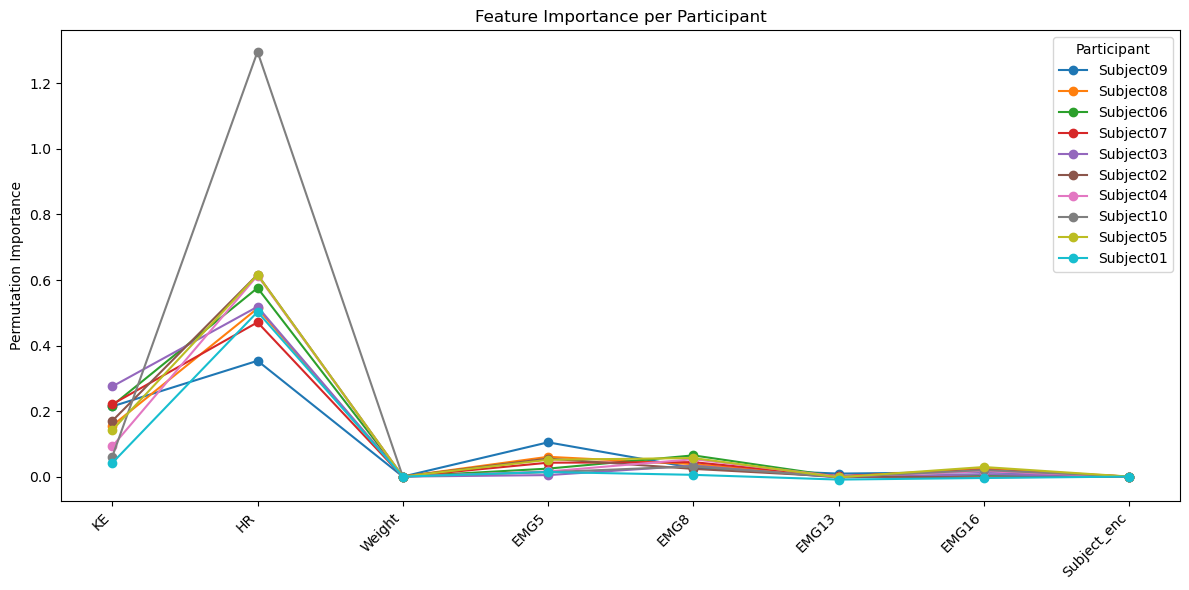

In [3]:
# SVR Linear train 8, test 2 ; MinMaxScaler ; 5 fold subject CV
# USE THIS ONE
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
import numpy as np
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd
import seaborn as sns

# Load dataset
filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Subject", "EE", "Weight", "EMG5", "EMG8","EMG13","EMG16"]]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject_enc"] = le.fit_transform(LR_df["Subject"])
subjects = LR_df["Subject_enc"].values
original_subject_labels = LR_df["Subject"].values


x = LR_df.drop(columns=["EE", "Subject"])
y = LR_df["EE"]

uniqueSubjects = np.unique(subjects)

model = make_pipeline(MinMaxScaler(), SVR(kernel="linear"))
gkf = GroupKFold(n_splits=10)

mseTrain, mseTest, r2train, r2test = [], [], [], []
fold_feature_importance = []
fold_subjects = []
for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(x, y, groups=subjects), start=1):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    test_subject = np.unique(original_subject_labels[test_idx])[0]
    fold_subjects.append(test_subject)

    model.fit(x_train, y_train)
    y_trainPred = model.predict(x_train)
    y_testPred = model.predict(x_test)

    fold_mse_train = mean_squared_error(y_train, y_trainPred)
    fold_mse_test = mean_squared_error(y_test, y_testPred)
    fold_r2_train = r2_score(y_train, y_trainPred)
    fold_r2_test = r2_score(y_test, y_testPred)

    mseTrain.append(fold_mse_train)
    mseTest.append(fold_mse_test)
    r2train.append(fold_r2_train)
    r2test.append(fold_r2_test)

    perm_importance = permutation_importance(model, x_test, y_test, random_state=42)
    fold_feature_importance.append(perm_importance.importances_mean)

    # Print per-fold results
    print(f"Test Subject: {test_subject}")
    print(f"     Train MSE: {fold_mse_train:.4f} , Test MSE: {fold_mse_test:.4f}")
    print(f"     Train R²:  {fold_r2_train:.4f} , Test R²:  {fold_r2_test:.4f}")
    print("\n")

print("\n")
print(f"Average MSE Train: {np.mean(mseTrain):.4f} , Average MSE Test: {np.mean(mseTest):.4f}")
print(f"Average R² Train:  {np.mean(r2train):.4f} , Average R² Test:  {np.mean(r2test):.4f}")

fi_df = pd.DataFrame(fold_feature_importance, columns=x.columns)

# Plot feature importance per participant
plt.figure(figsize=(12, 6))
for idx, subject in enumerate(fold_subjects):
    plt.plot(x.columns, fi_df.iloc[idx], marker='o', label=subject)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Permutation Importance")
plt.title("Feature Importance per Participant")
plt.legend(title="Participant")
plt.tight_layout()
plt.show()


In [91]:
# SVR Linear train 5, test 1 ; MinMaxScaler ; 6-fold CV by Activity
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Activity", "Subject", "EE", "Weight", "EMG5", "EMG8","EMG13","EMG16"]]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject_enc"] = le.fit_transform(LR_df["Subject"])
subjects = LR_df["Subject_enc"].values
original_subject_labels = LR_df["Subject"].values
le_a = LabelEncoder()
LR_df["Activity"] = le_a.fit_transform(LR_df["Activity"])  

x = LR_df.drop(columns=["EE","Subject","Activity"])
y = LR_df["EE"]

activity = LR_df["Activity"].values

model = make_pipeline(MinMaxScaler(), SVR(kernel="linear"))
gkf = GroupKFold(n_splits=6)

mseTrain, mseTest, r2train, r2test = [], [], [], []

for train_idx, test_idx in gkf.split(x, y, groups=activity):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(x_train, y_train)
    y_trainPred = model.predict(x_train)
    y_testPred = model.predict(x_test)

    fold_mse_train = mean_squared_error(y_train, y_trainPred)
    fold_mse_test = mean_squared_error(y_test, y_testPred)
    fold_r2_train = r2_score(y_train, y_trainPred)
    fold_r2_test = r2_score(y_test, y_testPred)

    mseTrain.append(fold_mse_train)
    mseTest.append(fold_mse_test)
    r2train.append(fold_r2_train)
    r2test.append(fold_r2_test)


    print(f"     Train MSE: {fold_mse_train:.4f} , Test MSE: {fold_mse_test:.4f}")
    print(f"     Train R²:  {fold_r2_train:.4f} , Test R²:  {fold_r2_test:.4f}")
    print("\n")
    

print(f"Average MSE Train: {np.mean(mseTrain):.4f}")
print(f"Average MSE Test: {np.mean(mseTest):.4f}")
print(f"Average R² Train:  {np.mean(r2train):.4f}")
print(f"Average R² Test:  {np.mean(r2test):.4f}")


     Train MSE: 0.7036 , Test MSE: 2.4778
     Train R²:  0.9226 , Test R²:  0.7727


     Train MSE: 0.9167 , Test MSE: 5.7106
     Train R²:  0.8373 , Test R²:  0.5811


     Train MSE: 1.1888 , Test MSE: 0.6988
     Train R²:  0.8953 , Test R²:  0.4906


     Train MSE: 1.2286 , Test MSE: 0.3485
     Train R²:  0.8734 , Test R²:  0.4426


     Train MSE: 1.1691 , Test MSE: 0.7545
     Train R²:  0.8914 , Test R²:  0.3942


     Train MSE: 1.1780 , Test MSE: 0.3541
     Train R²:  0.8793 , Test R²:  0.5030


Average MSE Train: 1.0641
Average MSE Test: 1.7240
Average R² Train:  0.8832
Average R² Test:  0.5307


Test Subject: Subject09
     Train MSE: 1.1716 , Test MSE: 0.9874
     Train R²:  0.8770 , Test R²:  0.8981


Test Subject: Subject08
     Train MSE: 1.1939 , Test MSE: 0.8923
     Train R²:  0.8788 , Test R²:  0.8702


Test Subject: Subject06
     Train MSE: 1.1342 , Test MSE: 1.4077
     Train R²:  0.8816 , Test R²:  0.8490


Test Subject: Subject07
     Train MSE: 1.0638 , Test MSE: 2.7281
     Train R²:  0.8828 , Test R²:  0.7886


Test Subject: Subject03
     Train MSE: 1.1322 , Test MSE: 1.4151
     Train R²:  0.8806 , Test R²:  0.8557


Test Subject: Subject02
     Train MSE: 1.1544 , Test MSE: 1.2287
     Train R²:  0.8770 , Test R²:  0.8865


Test Subject: Subject04
     Train MSE: 1.1381 , Test MSE: 1.3658
     Train R²:  0.8810 , Test R²:  0.8549


Test Subject: Subject10
     Train MSE: 1.1915 , Test MSE: 0.8532
     Train R²:  0.8800 , Test R²:  0.7917


Test Subject: Subject05
     Train MSE: 1.1358 , Test MSE: 1.6085
     Train R²:  0.8777 , Test R²:  0.8640


Test Subje

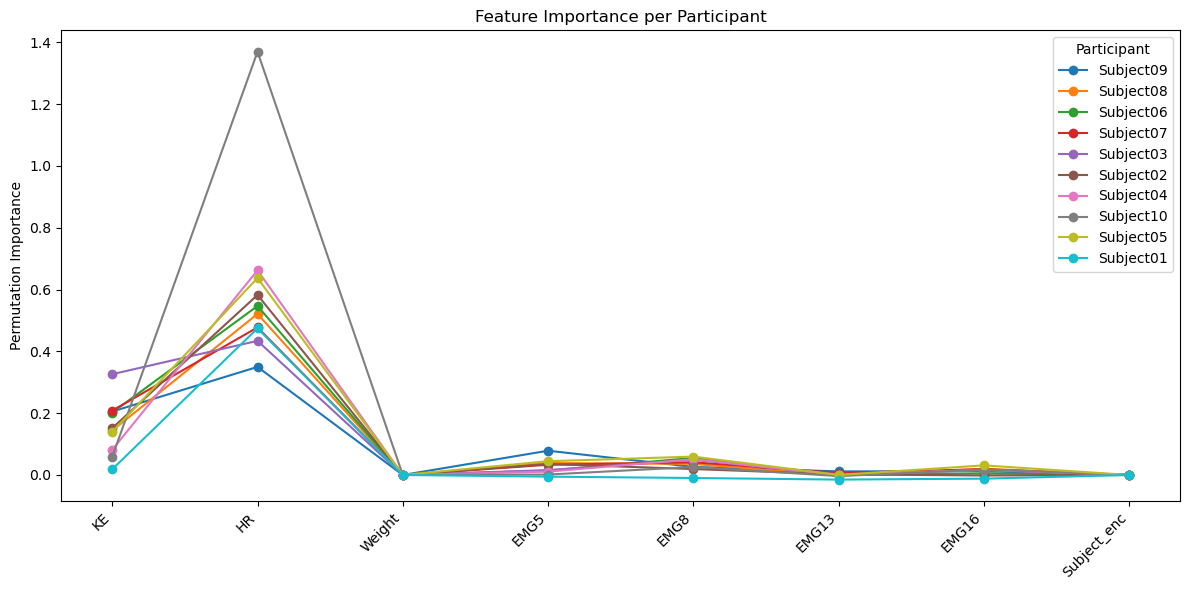

In [7]:
# SVR Linear train 8, test 2 ; MinMaxScaler ; 5 fold subject CV
# USE THIS ONE - 15 SECONDS
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
import numpy as np
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd
import seaborn as sns

# Load dataset
filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/EE_Dataset15.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Subject", "EE", "Weight", "EMG5", "EMG8","EMG13","EMG16"]]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject_enc"] = le.fit_transform(LR_df["Subject"])
subjects = LR_df["Subject_enc"].values
original_subject_labels = LR_df["Subject"].values


x = LR_df.drop(columns=["EE", "Subject"])
y = LR_df["EE"]

uniqueSubjects = np.unique(subjects)

model = make_pipeline(MinMaxScaler(), SVR(kernel="linear"))
gkf = GroupKFold(n_splits=10)

mseTrain, mseTest, r2train, r2test = [], [], [], []
fold_feature_importance = []
fold_subjects = []
for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(x, y, groups=subjects), start=1):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    test_subject = np.unique(original_subject_labels[test_idx])[0]
    fold_subjects.append(test_subject)

    model.fit(x_train, y_train)
    y_trainPred = model.predict(x_train)
    y_testPred = model.predict(x_test)

    fold_mse_train = mean_squared_error(y_train, y_trainPred)
    fold_mse_test = mean_squared_error(y_test, y_testPred)
    fold_r2_train = r2_score(y_train, y_trainPred)
    fold_r2_test = r2_score(y_test, y_testPred)

    mseTrain.append(fold_mse_train)
    mseTest.append(fold_mse_test)
    r2train.append(fold_r2_train)
    r2test.append(fold_r2_test)

    perm_importance = permutation_importance(model, x_test, y_test, random_state=42)
    fold_feature_importance.append(perm_importance.importances_mean)

    # Print per-fold results
    print(f"Test Subject: {test_subject}")
    print(f"     Train MSE: {fold_mse_train:.4f} , Test MSE: {fold_mse_test:.4f}")
    print(f"     Train R²:  {fold_r2_train:.4f} , Test R²:  {fold_r2_test:.4f}")
    print("\n")

print("\n")
print(f"Average MSE Train: {np.mean(mseTrain):.4f} , Average MSE Test: {np.mean(mseTest):.4f}")
print(f"Average R² Train:  {np.mean(r2train):.4f} , Average R² Test:  {np.mean(r2test):.4f}")

fi_df = pd.DataFrame(fold_feature_importance, columns=x.columns)

# Plot feature importance per participant
plt.figure(figsize=(12, 6))
for idx, subject in enumerate(fold_subjects):
    plt.plot(x.columns, fi_df.iloc[idx], marker='o', label=subject)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Permutation Importance")
plt.title("Feature Importance per Participant")
plt.legend(title="Participant")
plt.tight_layout()
plt.show()


In [14]:
# SVR Linear train 5, test 1 ; MinMaxScaler ; 6-fold CV by Activity ; 15 second bins
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Display precision settings
np.set_printoptions(precision=3, suppress=True)

# Load dataset
filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/EE_Dataset15.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Activity", "Subject", "EE", "Weight", 
               "EMG5", "EMG8", "EMG13", "EMG16"]]
LR_df.fillna(0, inplace=True)

# Encode subjects
le_subject = LabelEncoder()
LR_df["Subject_enc"] = le_subject.fit_transform(LR_df["Subject"])
subjects = LR_df["Subject_enc"].values
original_subject_labels = LR_df["Subject"].values

# Encode activities
le_activity = LabelEncoder()
LR_df["Activity_enc"] = le_activity.fit_transform(LR_df["Activity"])  

# Define X, y, and groups
x = LR_df.drop(columns=["EE", "Subject", "Activity", "Activity_enc"])
y = LR_df["EE"]
activity = LR_df["Activity_enc"].values  # groups for GroupKFold

# Model and cross-validation
model = make_pipeline(MinMaxScaler(), SVR(kernel="linear"))
gkf = GroupKFold(n_splits=6)

mseTrain, mseTest, r2train, r2test = [], [], [], []

for fold, (train_idx, test_idx) in enumerate(gkf.split(x, y, groups=activity), start=1):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(x_train, y_train)
    y_trainPred = model.predict(x_train)
    y_testPred = model.predict(x_test)

    fold_mse_train = mean_squared_error(y_train, y_trainPred)
    fold_mse_test = mean_squared_error(y_test, y_testPred)
    fold_r2_train = r2_score(y_train, y_trainPred)
    fold_r2_test = r2_score(y_test, y_testPred)

    mseTrain.append(fold_mse_train)
    mseTest.append(fold_mse_test)
    r2train.append(fold_r2_train)
    r2test.append(fold_r2_test)

    # Get actual activity names instead of encoded values
    train_acts = le_activity.inverse_transform(activity[train_idx])
    test_acts = le_activity.inverse_transform(activity[test_idx])

    print(f"Activity: {np.unique(test_acts)}")
    print(f"  Train MSE: {fold_mse_train:.4f} , Test MSE: {fold_mse_test:.4f}")
    print(f"  Train R²:  {fold_r2_train:.4f} , Test R²:  {fold_r2_test:.4f}")
    print("\n")

# averages across folds
print(f"Average MSE Train: {np.mean(mseTrain):.4f}")
print(f"Average MSE Test:  {np.mean(mseTest):.4f}")
print(f"Average R² Train:  {np.mean(r2train):.4f}")
print(f"Average R² Test:   {np.mean(r2test):.4f}")


Activity: ['Incline']
  Train MSE: 0.7558 , Test MSE: 2.4512
  Train R²:  0.9168 , Test R²:  0.7751


Activity: ['Running']
  Train MSE: 0.9746 , Test MSE: 4.5047
  Train R²:  0.8270 , Test R²:  0.6695


Activity: ['Cycling']
  Train MSE: 1.2451 , Test MSE: 0.8152
  Train R²:  0.8904 , Test R²:  0.4058


Activity: ['Walking']
  Train MSE: 1.2928 , Test MSE: 0.3767
  Train R²:  0.8668 , Test R²:  0.3974


Activity: ['Stairs']
  Train MSE: 1.2306 , Test MSE: 0.8669
  Train R²:  0.8857 , Test R²:  0.3039


Activity: ['Backwards']
  Train MSE: 1.2344 , Test MSE: 0.4480
  Train R²:  0.8735 , Test R²:  0.3712


Average MSE Train: 1.1222
Average MSE Test:  1.5771
Average R² Train:  0.8767
Average R² Test:   0.4872
